---
numbering:
  enumerator: "19.%s"
  equation:
    template: "%s"  
---

(chap_interp)=
# Interpretability

This chapter is dedicated to the techniques that help understand the way models process inputs into outputs. Two recent books (@molnar2019interpretable available at https://christophm.github.io/interpretable-ml-book/, and @biecek2021explanatory, available at https://ema.drwhy.ai) are entirely devoted to this topic and we highly recommend to have a look at them. The survey of @belle2020principles is also worthwhile. Another more introductory and less technical reference is @hall2019introduction.
Obviously, in this chapter, we will adopt a tone which is factor-investing orientated and discuss examples related to ML models trained on a financial dataset.

Quantitative tools that aim for interpretability of ML models are required to satisfy two simple conditions:

1. That they provide information about the model.
2. That they are highly comprehensible.

Often, these tools generate graphical outputs which are easy to read and yield immediate conclusions.

In attempts to white-box complex machine learning models, one dichotomy stands out:

- **Global models** seek to determine the relative role of features in the construction of the predictions once the model has been trained. This is done at the global level, so that the patterns that are shown in the interpretation hold *on average* over the whole training set.
- **Local models** aim to characterize how the model behaves around one particular instance by considering small variations around this instance. The way these variations are processed by the original model allows to simplify it by approximating it, e.g., in a linear fashion. This approximation can for example determine the sign and magnitude of the impact of each relevant feature in the vicinity of the original instance.

@molnar2019interpretable proposes another classification of interpretability solutions by splitting interpretations that depend on one particular model (e.g., linear regression or decision tree) versus the interpretations that can be obtained for any kind of model. In the sequel, we present the methods according to the global versus local dichotomy.

Beyond the traditional approaches we present below, we wish to highlight two other methods: Sirus [@benard2021sirus] and Rulefit [@friedman2008predictive].

## Global interpretations

(surr)=
### Simple models as surrogates

Let us start with the simplest example of all. In a linear model,

$$y_i=\alpha+\sum_{k=1}^K\beta_kx_i^k+\epsilon_i,$$

the following elements are usually extracted from the estimation of the $\beta_k$:

- the $R^2$, which appreciates the **global fit** of the model (possibly penalized to prevent overfitting with many regressors). The $R^2$ is usually computed in-sample;
- the sign of the estimates $\hat{\beta}_k$, which indicates the **direction** of the impact of each feature $x^k$ on $y$;
- the $t$-statistics $t_{\hat{\beta_k}}$, which evaluate the **magnitude** of this impact: regardless of its direction, large statistics in absolute value reveal prominent variables. Often, the $t$-statistics are translated into $p$-values which are computed under some suitable distributional assumptions.

The last two indicators are useful because they inform the user on which features matter the most and on the sign of the effect of each predictor. This gives a simplified view of how the model processes the features into the output. Most tools that aim to explain black boxes follow the same principles.

Decision trees, because they are easy to picture, are also great models for interpretability. Thanks to this favorable feature, they are target benchmarks for simple models. Recently, @vidal2020born propose a method to reduce an ensemble of trees into a unique tree. The aim is to propose a simpler model that behaves exactly like the complex one.

More generally, it is an intuitive idea to resort to simple models to proxy more complex algorithms. One simple way to do so is to build so-called **surrogate** models. The process is simple:

1. train the original model $f$ on features $\textbf{X}$ and labels $\textbf{y}$;
2. train a simpler model $g$ to explain the predictions of the trained model $\hat{f}$ given the features $\textbf{X}$:

$$\hat{f}(\textbf{X})=g(\textbf{X})+\textbf{error}$$

The estimated model $\hat{g}$ explains how the initial model $\hat{f}$ maps the features into the labels. To illustrate this, we use a decision tree as a surrogate model. The simpler model is a tree with a depth of two.

In [ ]:
%config InlineBackend.figure_formats = ['png', 'pdf']

# A fitted scikit-learn estimator otherwise renders as a large interactive
# diagram that MyST uses for both the website and the PDF. The plain repr
# shows the same parameters in one line and suits both.
import sklearn
sklearn.set_config(display='text')


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Building the data & import functions
from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()

# Define separation date and create samples
separation_date = "2017-01-15"
training_sample = data_ml[data_ml['date'] <= separation_date].dropna()
testing_sample = data_ml[data_ml['date'] > separation_date].dropna()

In [2]:
# Train a random forest model (recycled from Chapter 6)
np.random.seed(42)
fit_RF = RandomForestRegressor(
    n_estimators=40,
    max_samples=10000,
    bootstrap=True,
    min_samples_leaf=250,
    max_features=30,
    random_state=42
)
fit_RF.fit(training_sample[features], training_sample['R1M'])

# Get predictions from the random forest
rf_predictions = fit_RF.predict(training_sample[features])

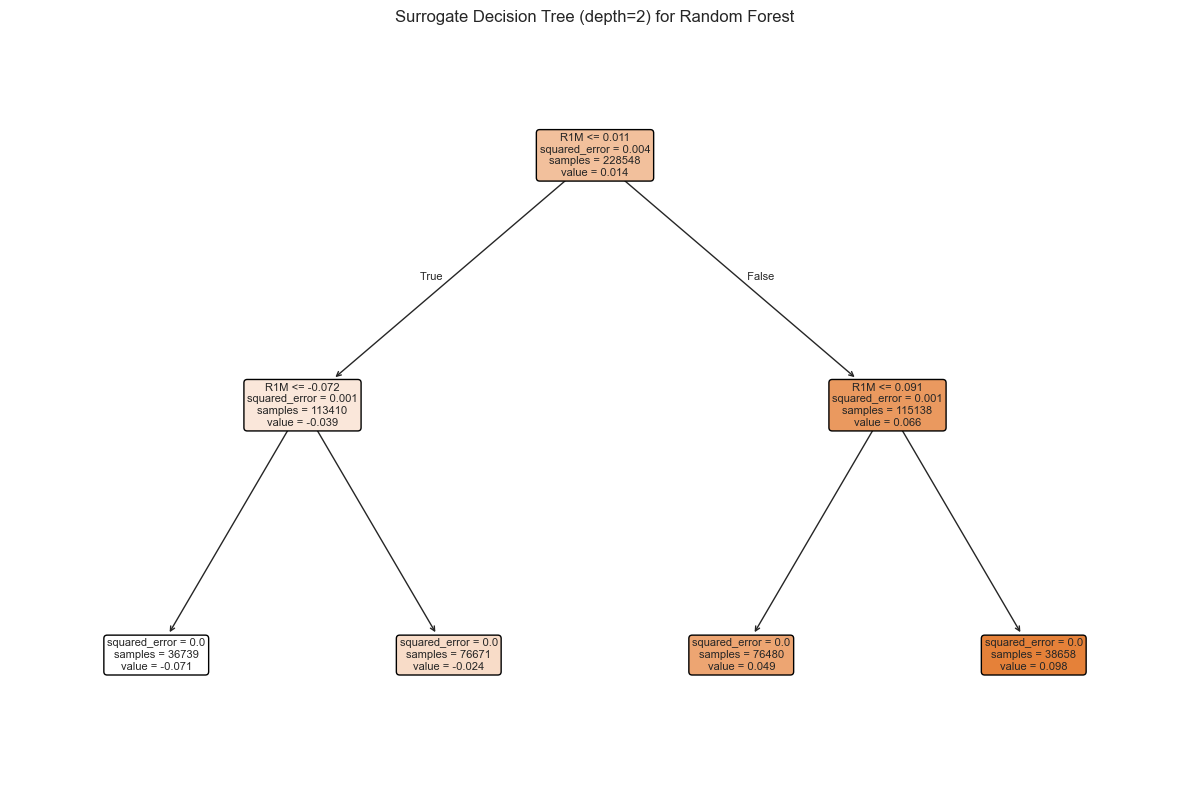

In [3]:
#| label: fig-imlsurr
#| fig-cap: "Example of surrogate tree."

# Train a simple decision tree as surrogate model
surrogate_tree = DecisionTreeRegressor(max_depth=2, random_state=42)
surrogate_tree.fit(training_sample[features], rf_predictions)

# Plot the surrogate tree
plt.figure(figsize=(12, 8))
plot_tree(surrogate_tree, 
          feature_names=features,
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Surrogate Decision Tree (depth=2) for Random Forest')
plt.tight_layout()
plt.show()

The representation of the tree shows the conditions in each node and the resulting predictions. The four possible outcomes (determined by the conditions) yield information about which features drive the model's predictions. This surrogate model helps understand how the random forest processes its inputs.

(variable-importance)=
### Variable importance (tree-based)

One incredibly favorable feature of simple decision trees is their interpretability. Their visual representation is clear and straightforward. Just like regressions (which are another building block in ML), simple trees are easy to comprehend and do not suffer from the black-box rebuke that is often associated with more sophisticated tools.

Indeed, both random forests and boosted trees fail to provide perfectly accurate accounts of what is happening inside the engine. In contrast, it is possible to compute the aggregate share (or importance) of each feature in the determination of the structure of the tree once it has been trained.

After training, it is possible to compute, at each node $n$ the gain $G(n)$ obtained by the subsequent split if there are any, i.e., if the node is not a terminal leaf. It is also easy to determine which variable is chosen to perform the split, hence we write $\mathcal{N}_k$ the set of nodes for which feature $k$ is chosen for the partition. Then, the global importance of each feature is given by

$$I(k)=\sum_{n\in \mathcal{N}_k}G(n),$$

and it is often rescaled so that the sum of $I(k)$ across all $k$ is equal to one. In this case, $I(k)$ measures the relative contribution of feature $k$ in the reduction of loss during the training. A variable with high importance will have a greater impact on predictions. Generally, these variables are those that are located close to the root of the tree.

Below, we take a look at the results obtained from the tree-based models trained in Chapter {ref}`chap_trees`. We start by recycling the output from the three regression models we used. Notice that each fitted output has its own structure and importance vectors have different names.

In [4]:
# Train tree-based models
# 1. Simple decision tree
fit_tree = DecisionTreeRegressor(
    min_samples_leaf=1500,
    min_samples_split=4000,
    ccp_alpha=0.0001,
    max_depth=5
)
fit_tree.fit(training_sample[features], training_sample['R1M'])

# 2. XGBoost (on extreme values)
q20 = training_sample['R1M'].quantile(0.2)
q80 = training_sample['R1M'].quantile(0.8)
train_extreme = training_sample[
    (training_sample['R1M'] < q20) | (training_sample['R1M'] > q80)
]
train_features_xgb = train_extreme[features].values
train_label_xgb = train_extreme['R1M'].values
train_matrix_xgb = xgb.DMatrix(data=train_features_xgb, label=train_label_xgb)

params_xgb = {
    'eta': 0.4,
    'objective': 'reg:squarederror',
    'max_depth': 4,
    'verbosity': 0
}
fit_xgb = xgb.train(params=params_xgb, dtrain=train_matrix_xgb, num_boost_round=18)

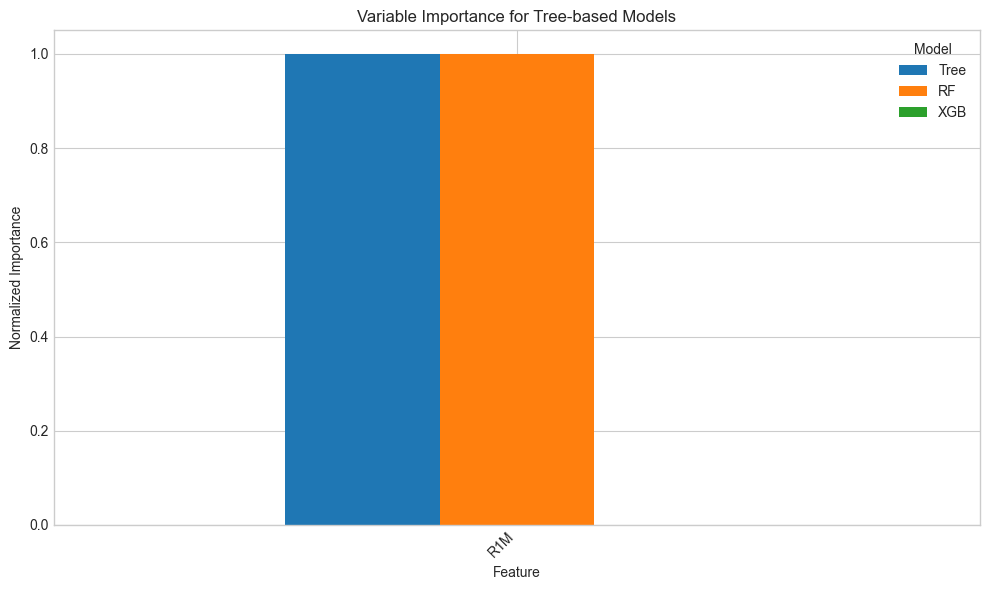

In [5]:
#| label: fig-VItrees
#| fig-cap: "Variable importance for tree-based models."

# Get variable importance from each model
# Tree importance (only non-zero features)
tree_vi = pd.Series(fit_tree.feature_importances_, index=features)
tree_vi = tree_vi[tree_vi > 0]

# Random Forest importance
rf_vi = pd.Series(fit_RF.feature_importances_, index=features)

# XGBoost importance
xgb_vi_dict = fit_xgb.get_score(importance_type='gain')
xgb_vi = pd.Series(xgb_vi_dict)

# Get common features (those present in the simple tree)
common_features = tree_vi.index.tolist()

# Create comparison dataframe
vi_comparison = pd.DataFrame({
    'Tree': tree_vi,
    'RF': rf_vi.reindex(common_features),
    'XGB': xgb_vi.reindex(common_features)
}).fillna(0)

# Normalize each column
vi_comparison = vi_comparison.apply(lambda x: x / x.sum())

# Plot
vi_comparison.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Feature')
plt.ylabel('Normalized Importance')
plt.title('Variable Importance for Tree-based Models')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

Given the way the graph is coded, the figure is in fact misleading. Indeed, by construction, the simple tree model only has a small number of features with nonzero importance. In contrast, because random forest and boosted trees are much more complex, they give some importance to many predictors. The graph shows the variables related to the simple tree model only. For scale reasons, the normalization is performed *after* the subset of features is chosen. We preferred to limit the number of features shown on the graph for obvious readability concerns.

There are differences in the way the models rely on the features. For instance, the most important feature changes from a model to the other.

One defining property of random forests is that they give a chance to all features. Indeed, by randomizing the choice of predictors, each individual exogenous variable has a shot at explaining the label. Along with boosted trees, the allocation of importance is more balanced across predictors, compared to the simple tree which puts most of its eggs in just a few baskets.

### Variable importance (agnostic)

The idea of quantifying the importance of each feature in the learning process can be extended to nontree-based models. We refer to the papers mentioned in the study by @fisher2018all for more information on this stream of the literature. The premise is the same as above: the aim is to quantify to what extent one feature contributes to the learning process.

One way to track the added value of one particular feature is to look at what happens if its values inside the training set are entirely shuffled. If the original feature plays an important role in the explanation of the dependent variable, then the shuffled version of the feature will lead to a much higher loss.

The baseline method to assess feature importance in the general case is the following:

1. Train the model on the original data and compute the associated loss $l^*$.
2. For each feature $k$, create a new training dataset in which the feature's values are randomly permuted. Then, evaluate the loss $l_k$ of the model based on this altered sample.
3. Rank the variable importance of each feature, computed as a difference $\text{VI}_k=l_k-l^*$ or a ratio $\text{VI}_k=l_k/l^*$.

Whether to compute the losses on the training set or the testing set is an open question and remains to the appreciation of the analyst.
The above procedure is of course random and can be repeated so that the importances are averaged over several trials: this improves the stability of the results.

Below, we implement this algorithm manually for a ridge regression model. We start by the first step: computing the loss on the original training sample.

In [6]:
# Train ridge regression
X_train = training_sample[features].values
y_train = training_sample['R1M'].values

fit_ridge = Ridge(alpha=0.01)
fit_ridge.fit(X_train, y_train)

# Compute baseline loss
l_star = np.mean((y_train - fit_ridge.predict(X_train))**2)
print(f"Baseline MSE: {l_star:.6f}")

Baseline MSE: 0.000000


Next, we evaluate the loss when each of the predictors has been sequentially shuffled. To reduce computation time, we only make one round of shuffling.

In [7]:
# Get the features that appeared in the tree model
selected_features = tree_vi.index.tolist()

# Compute loss for each shuffled feature
losses = []
for feat_name in selected_features:
    temp_data = training_sample[features].copy()
    # Shuffle the feature values
    temp_data[feat_name] = np.random.permutation(temp_data[feat_name].values)
    X_temp = temp_data.values
    loss = np.mean((y_train - fit_ridge.predict(X_temp))**2)
    losses.append(loss)

Finally, we plot the results.

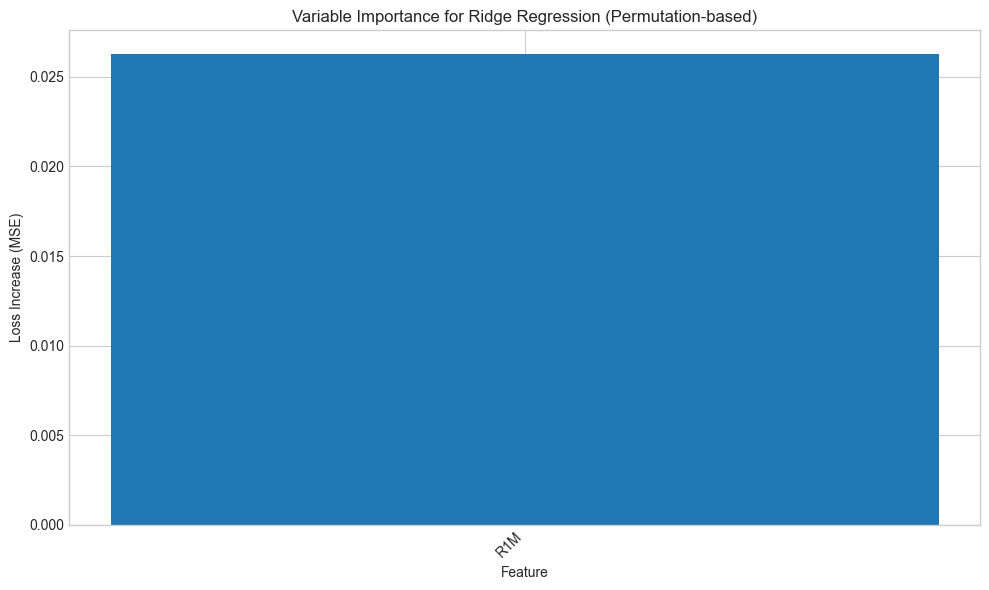

In [8]:
#| label: fig-VIglobal
#| fig-cap: "Variable importance for a ridge regression model."

# Create dataframe with importance (loss increase)
vi_ridge = pd.DataFrame({
    'Feature': selected_features,
    'Importance': np.array(losses) - l_star
})

# Plot
plt.figure(figsize=(10, 6))
plt.bar(vi_ridge['Feature'], vi_ridge['Importance'])
plt.xlabel('Feature')
plt.ylabel('Loss Increase (MSE)')
plt.title('Variable Importance for Ridge Regression (Permutation-based)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The resulting importances are in line with those of the tree-based models: the most prominent variables closely match the variables from the previous figure. Note that in some cases, the score can even be negative, which means that the predictions are more accurate than the baseline model when the values of the predictor are shuffled!

### Partial dependence plot

Partial dependence plots (PDPs) aim at showing the relationship between the output of a model and the value of a feature (we refer to section 8.2 of @friedman2001greedy for an early treatment of this subject).

Let us fix a feature $k$. We want to understand the **average impact** of $k$ on the predictions of the trained model $\hat{f}$. In order to do so, we assume that the feature space is random and we split it in two: $k$ versus $-k$, which stands for all features except for $k$. The partial dependence plot is defined as

$$
\bar{f}_k(x_k)=\mathbb{E}[\hat{f}(\textbf{x}_{-k},x_k)]=\int \hat{f}(\textbf{x}_{-k},x_k)d\mathbb{P}_{-k}(\textbf{x}_{-k}),
$$ (eq:pdp)

where $d\mathbb{P}_{-k}(\cdot)$ is the (multivariate) distribution of the non-$k$ features $\textbf{x}_{-k}$. The above function takes the feature values $x_k$ as argument and keeps all other features frozen via their sample distributions: this shows the impact of feature $k$ solely. In practice, the average is evaluated using Monte-Carlo simulations:

$$
\bar{f}_k(x_k)\approx \frac{1}{M}\sum_{m=1}^M\hat{f}\left(x_k,\textbf{x}_{-k}^{(m)}\right),
$$ (eq:pdpMC)

where $\textbf{x}_{-k}^{(m)}$ are independent samples of the non-$k$ features.

Theoretically, PDPs could be computed for more than one feature at a time. In practice, this is only possible for two features (yielding a 3D surface) and is more computationally intense.

We illustrate this concept below, using sklearn's `PartialDependenceDisplay`. The model we seek to explain is the random forest built earlier. We choose to test the impact of the price-to-book ratio on the outcome of the model.

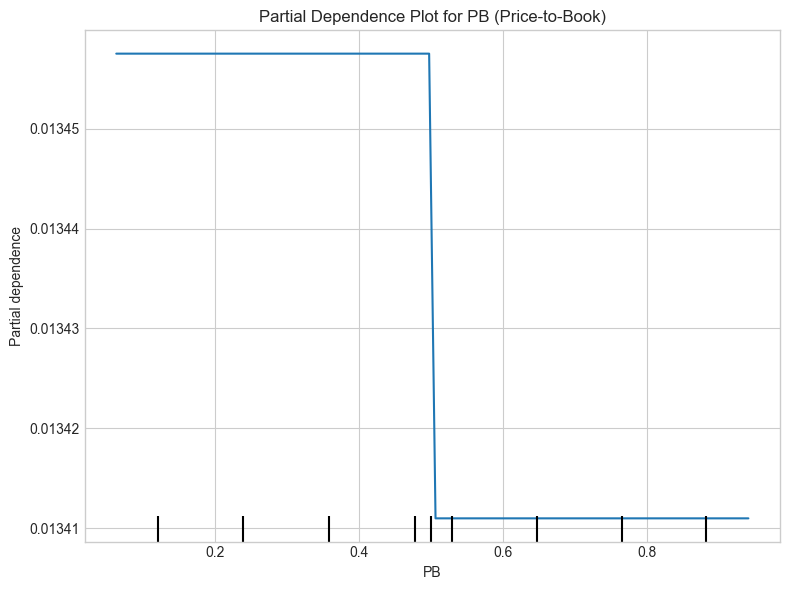

In [9]:
#| label: fig-pdp
#| fig-cap: "Partial dependence plot for the price-to-book ratio on the random forest model."

# Find the index of PB feature
pb_idx = features.index('PB')

# Create partial dependence plot
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    fit_RF,
    training_sample[features],
    features=[pb_idx],
    feature_names=features,
    ax=ax
)
plt.title('Partial Dependence Plot for PB (Price-to-Book)')
plt.tight_layout()
plt.show()

The average impact of the price-to-book ratio on the predictions is decreasing. This was somewhat expected, given the conditional average of the dependent variable given the price-to-book ratio. When the price-to-book ratio is low, firms are undervalued. Hence, their higher returns are in line with the *value* premium.

Finally, we refer to @zhao2019causal for a theoretical discussion on the *causality* property of PDPs. Indeed, a deep look at the construction of the PDPs suggests that they could be interpreted as a causal representation of the feature on the model's output.

## Local interpretations

Whereas global interpretations seek to assess the impact of features on the output *overall*, local methods try to quantify the behavior of the model on particular instances or the neighborhood thereof. Local interpretability has recently gained traction and many papers have been published on this topic. Below, we outline the most widespread methods.

### LIME

LIME (Local Interpretable Model-Agnostic Explanations) is a methodology originally proposed by @ribeiro2016should. Their aim is to provide a faithful account of the model under two constraints:

- **simple interpretability**, which implies a limited number of variables with visual or textual representation. This is to make sure any human can easily understand the outcome of the tool;
- **local faithfulness**: the explanation holds for the vicinity of the instance.

The original (black-box) model is $f$ and we assume we want to approximate its behavior around instance $x$ with the interpretable model $g$. The simple function $g$ belongs to a larger class $G$. The vicinity of $x$ is denoted $\pi_x$ and the complexity of $g$ is written $\Omega(g)$. LIME seeks an interpretation of the form

$$\xi(x)=\underset{g \in G}{\text{argmin}} \, \mathcal{L}(f,g,\pi_x)+\Omega(g),$$

where $\mathcal{L}(f,g,\pi_x)$ is the loss function (error/imprecision) induced by $g$ in the vicinity $\pi_x$ of $x$. The penalization $\Omega(g)$ is for instance the number of leaves or depth of a tree, or the number of predictors in a linear regression.

It now remains to define some of the above terms. The vicinity of $x$ is defined by $\pi_x(z)=e^{-D(x,z)^2/\sigma^2},$ where $D$ is some distance measure and $\sigma^2$ some scaling constant. We underline that this function decreases when $z$ shifts away from $x$.

The tricky part is the loss function. In order to minimize it, LIME generates artificial samples close to $x$ and averages/sums the error on the label that the simple representation makes. For simplicity, we assume a scalar output for $f$, hence the formulation is the following:

$$\mathcal{L}(f,g,\pi_x)=\sum_z \pi_x(z)(f(z)-g(z))^2$$

and the errors are weighted according to their distance from the initial instance $x$: the closest points get the largest weights. In its most basic implementation, the set of models $G$ consists of all linear models.

```{figure} images/lime.png
:name: fig-lime
:align: center
Simplistic explanation of LIME: the explained instance is surrounded by a red square. Five points are generated (the triangles) and a weighted linear model is fitted accordingly (dashed grey line).
```

For expositional clarity, we work with only one dependent variable. The original training sample is shown with the black points. The fitted (trained) model is represented with the blue line (smoothed conditional average) and we want to approximate how the model works around one particular instance which is highlighted by the red square around it. In order to build the approximation, we sample 5 new points around the instance (the 5 red triangles). Each triangle lies on the blue line (they are model predictions) and has a weight proportional to its size: the triangle closest to the instance has a bigger weight. Using weighted least-squares, we build a linear model that fits to these 5 points (the dashed grey line). This is the outcome of the approximation. It gives the two parameters of the model: the intercept and the slope. Both can be evaluated with standard statistical tests.

The sign of the slope is important. It is fairly clear that if the instance had been taken closer to $x=0$, the slope would have probably been almost flat and hence the predictor could be locally discarded. Another important detail is the number of sample points. In our explanation, we take only five, but in practice, a robust estimation usually requires around one thousand points or more. Indeed, when too few neighbors are sampled, the estimation risk is high and the approximation may be rough.

We proceed with an example of implementation. There are several steps:

1. Fit a model on some training data.
2. Wrap everything using the lime explainer.
3. Focus on a few predictors and see their impact over a few particular instances.

We start with the first step. This time, we work with a boosted tree model.

In [10]:
import lime
import lime.lime_tabular

# Train XGBoost model with sklearn interface for LIME compatibility
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    max_depth=5,
    learning_rate=0.5,
    gamma=0.1,
    colsample_bytree=1,
    min_child_weight=10,
    subsample=1,
    n_estimators=10,
    random_state=42
)
xgb_model.fit(training_sample[features_short], training_sample['R1M'])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.5, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=10, n_jobs=None,
             num_parallel_tree=None, ...)

Then, we head on to steps two and three. We resort to the `LimeTabularExplainer` class.

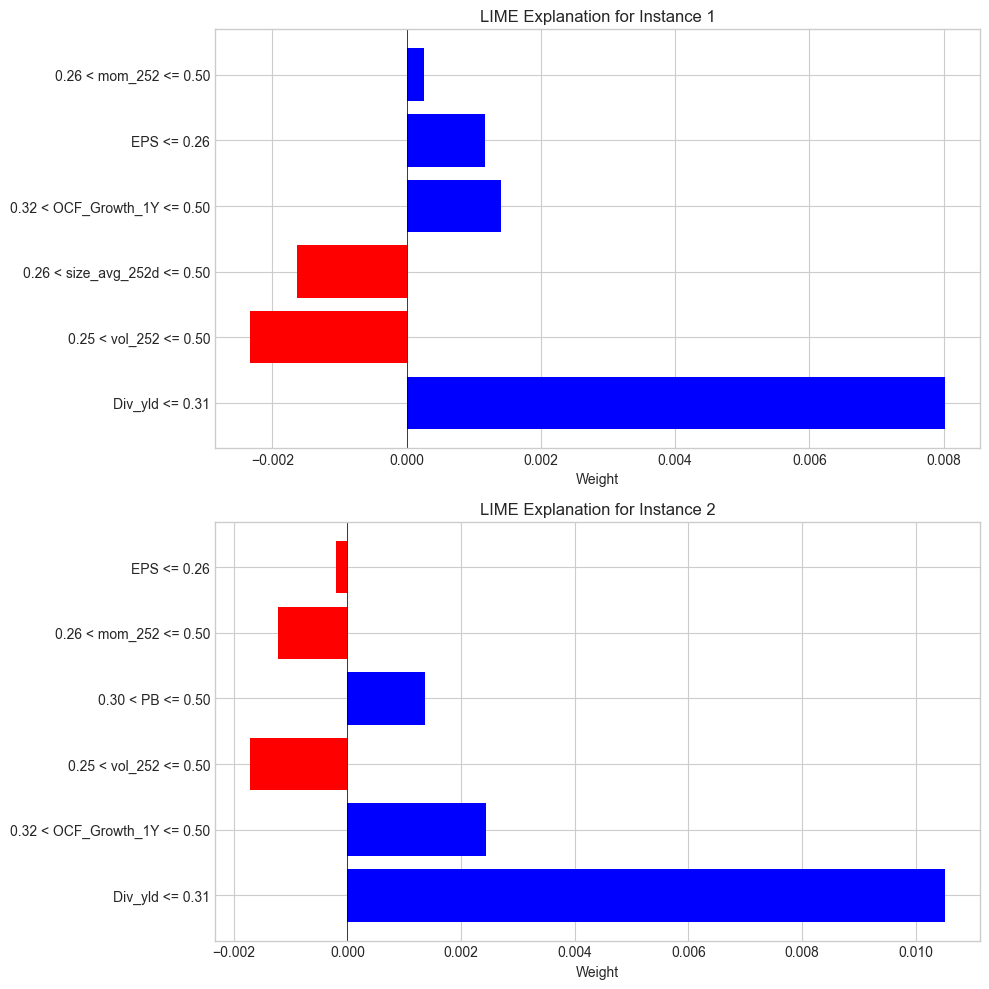

In [11]:
#| label: fig-lime_output
#| fig-cap: "LIME explanation for two instances."

# Create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_sample[features_short].values,
    feature_names=features_short,
    mode='regression'
)

# Explain first two instances
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for i, ax in enumerate(axes):
    instance = training_sample[features_short].iloc[i].values
    explanation = explainer.explain_instance(
        instance,
        xgb_model.predict,
        num_features=6,
        num_samples=900
    )
    
    # Extract feature importance
    exp_list = explanation.as_list()
    features_exp = [x[0] for x in exp_list]
    weights = [x[1] for x in exp_list]
    colors = ['blue' if w > 0 else 'red' for w in weights]
    
    ax.barh(features_exp, weights, color=colors)
    ax.set_xlabel('Weight')
    ax.set_title(f'LIME Explanation for Instance {i+1}')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

In each graph (one graph corresponds to the explanation around one instance), there are two types of information: the sign of the impact and the magnitude of the impact. The sign is revealed with the color (positive in blue, negative in red) and the magnitude is shown with the size of the bars.

Lastly, we briefly discuss the choice of distance function. It is used to evaluate the discrepancy between the true instance and a simulated one to give more or less weight to the prediction of the sampled instance. Our dataset comprises only numerical data; hence, the Euclidean distance is a natural choice:

$$\text{Euclidean}(\textbf{x}, \textbf{y})=\sqrt{\sum_{n=1}^N(x_n-y_n)^2}.$$

Another possible choice would be the Manhattan distance:

$$\text{Manhattan}(\textbf{x}, \textbf{y})=\sum_{n=1}^N|x_n-y_n|.$$

The problem with these two distances is that they fail to handle categorical variables. This is where the Gower distance steps in [@gower1971general]. The distance imposes a different treatment on features of different types (classes versus numbers essentially, but it can also handle missing data!). For categorical features, the Gower distance applies a binary treatment: the value is equal to 1 if the features are equal, and to zero if not (i.e., $1_{\{x_n=y_n\}}$). For numerical features, the spread is quantified as $1-\frac{|x_n-y_n|}{R_n}$, where $R_n$ is the maximum absolute value the feature can take. All similarity measurements are then aggregated to yield the final score. Note that in this case, the logic is reversed: $\textbf{x}$ and $\textbf{y}$ are very close if the Gower distance is close to one, and they are far away if the distance is close to zero.

### Shapley values

The approach of Shapley values is somewhat different compared to LIME and closer in spirit to PDPs. It originates from cooperative game theory [@shapley1953value]. The rationale is the following. One way to assess the impact (or usefulness) of a variable is to look at what happens if we remove this variable from the dataset. If this is very detrimental to the quality of the model (i.e., to the accuracy of its predictions), then it means that the variable is substantially valuable.

Shapley values have been used to attribute risk or performance of portfolios in @shalit2020shapley and @moehle2021portfolio.

Numerically, the simplest way to proceed is to take all variables and remove one to evaluate its predictive ability. Shapley values are computed on a larger scale because they consider all possible combinations of variables to which they add the target predictor. Formally, this gives:

$$
\phi_k=\sum_{S \subseteq \{x_1,\dots,x_K \} \backslash x_k}\underbrace{\frac{\text{Card}(S)!(K-\text{Card}(S)-1)!}{K!}}_{\text{weight of coalition}}\underbrace{\left(\hat{f}_{S \cup \{x_k\}}(S \cup \{x_k\})-\hat{f}_S(S)\right)}_{\text{gain when adding } x_k}
$$ (eq:shapley)

$S$ is any subset of the **coalition** that doesn't include feature $k$ and its size is Card($S$).
In the equation above, the model $f$ must be altered because it's impossible to evaluate $f$ when features are missing. In this case, there are several possible options:

- set the missing value to its average or median value (in the whole sample) so that its effect is some 'average' effect;
- directly compute an average value $\int_{\mathbb{R}} f(x_1,\dots,x_k,\dots,x_K)d\mathbb{P}_{x_k}$, where $d\mathbb{P}_{x_k}$ is the empirical distribution of $x_k$ in the sample.

Obviously, Shapley values can take a lot of time to compute if the number of predictors is large. We refer to @chen2018shapley for a discussion on a simplifying method that reduces computation times in this case.
Extensions of Shapley values for interpretability are studied in @lundberg2017unified.

The implementation of Shapley values is permitted in Python via the `shap` package. There are two restrictions compared to LIME. First, the features must be filtered upfront because all features are shown on the graph (which becomes illegible beyond 20 features). This is why in the code below, we use the short list of predictors.
Second, instances are analyzed one at a time.

We start by fitting a random forest model on the short features.

In [12]:
import shap

# Train random forest on short features
fit_RF_short = RandomForestRegressor(
    n_estimators=40,
    max_samples=10000,
    bootstrap=True,
    min_samples_leaf=250,
    max_features=4,
    random_state=42
)
fit_RF_short.fit(training_sample[features_short], training_sample['R1M'])

RandomForestRegressor(max_features=4, max_samples=10000, min_samples_leaf=250,
                      n_estimators=40, random_state=42)

We can then analyze the behavior of the model around the first instance of the training sample.

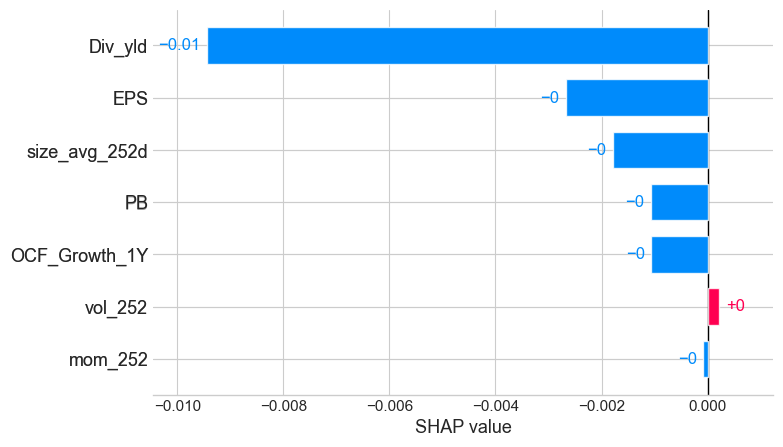

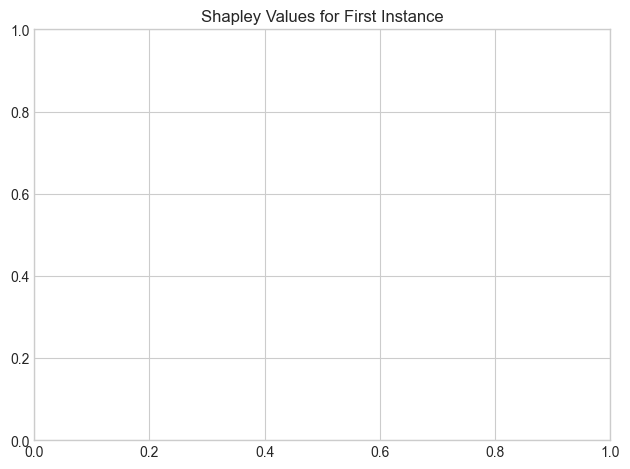

In [13]:
#| label: fig-shapley
#| fig-cap: "Illustration of the Shapley method."

# Create SHAP explainer
explainer_shap = shap.TreeExplainer(fit_RF_short)

# Compute SHAP values for the first instance
shap_values = explainer_shap.shap_values(training_sample[features_short].iloc[0:1])

# Plot waterfall for the first instance
shap.initjs()
plt.figure(figsize=(10, 6))
shap.plots.bar(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer_shap.expected_value,
        feature_names=features_short
    )
)
plt.title('Shapley Values for First Instance')
plt.tight_layout()
plt.show()

In the output shown in the figure, we again obtain the two crucial insights: **sign** of the impact of the feature and **relative importance** (compared to other features).

### Breakdown

Breakdown (see, e.g., @staniak2018explanations) is a mixture of ideas from PDPs and Shapley values. The core of breakdown is the so-called **relaxed model prediction** defined in Equation {eq}`eq:breakdown`. It is close in spirit to Equation {eq}`eq:pdp`. The difference is that we are working at the local level, i.e., on one particular observation, say $x^*$. We want to measure the impact of a set of predictors on the prediction associated to $x^*$; hence, we fix two sets $\textbf{k}$ (fixed features) and $-\textbf{k}$ (free features) and evaluate a **proxy** for the average prediction of the estimated model $\hat{f}$ when the set $\textbf{k}$ of predictors is fixed at the values of $x^*$, that is, equal to $x^*_{\textbf{k}}$ in the expression below:

$$
\tilde{f}_{\textbf{k}}(x^*)=\frac{1}{M}\sum_{m=1}^M \hat{f}\left(x^{(m)}_{-\textbf{k}},x^*_{\textbf{k}} \right).
$$ (eq:breakdown)

The $x^{(m)}$ in the above expression are either simulated values of instances or simply sampled values from the dataset. The notation implies that the instance has some values replaced by those of $x^*$, namely those that correspond to the indices $\textbf{k}$. When $\textbf{k}$ consists of all features, then $\tilde{f}_{\textbf{k}}(x^*)$ is equal to the raw model prediction $\hat{f}(x^*)$ and when $\textbf{k}$ is empty, it is equal to the average sample value of the label (constant prediction).

The quantity of interest is the so-called contribution of feature $j\notin \textbf{k}$ with respect to data point $x^*$ and set $\textbf{k}$:

$$\phi_{\textbf{k}}^j(x^*)=\tilde{f}_{\textbf{k} \cup j}(x^*)-\tilde{f}_{\textbf{k}}(x^*).$$

Just as for Shapley values, the above indicator computes an average impact when augmenting the set of predictors with feature $j$. By definition, it depends on the set $\textbf{k}$, so this is one notable difference with Shapley values (that span *all* permutations). In @staniak2018explanations, the authors devise a procedure that incrementally increases or decreases the set $\textbf{k}$. This greedy idea helps alleviate the burden of computing all possible combinations of features. Moreover, a very convenient property of their algorithm is that the sum of all contributions is equal to the predicted value:

$$\sum_j \phi_{\textbf{k}}^j(x^*)=f(x^*).$$

The visualization makes that very easy to see (as in the figure below).

In order to illustrate one implementation of breakdown, we use SHAP's waterfall plot which provides a similar visualization.

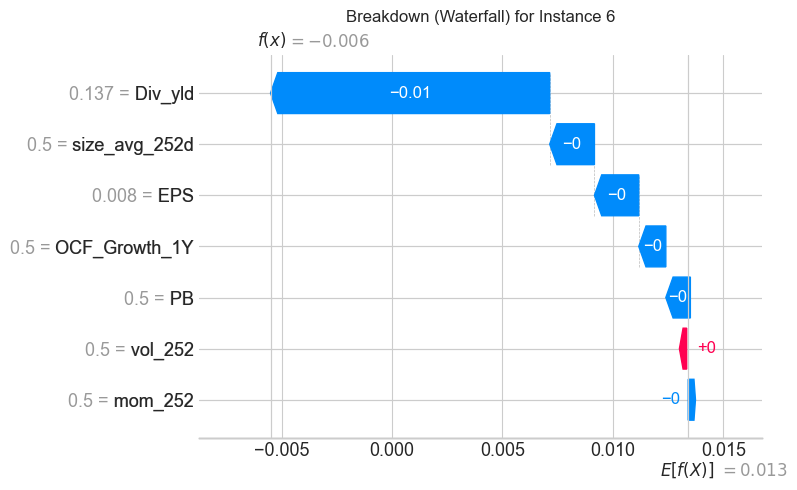

In [14]:
#| label: fig-breakdown
#| fig-cap: "Example of a breakdown output using SHAP waterfall plot."

# Use instance 6 (index 5) for breakdown example
instance_idx = 5
shap_values_instance = explainer_shap.shap_values(training_sample[features_short].iloc[instance_idx:instance_idx+1])

# Create waterfall plot (similar to breakdown)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_instance[0],
        base_values=explainer_shap.expected_value,
        data=training_sample[features_short].iloc[instance_idx].values,
        feature_names=features_short
    ),
    show=False
)
plt.title(f'Breakdown (Waterfall) for Instance {instance_idx + 1}')
plt.tight_layout()
plt.show()

The graphical output is intuitively interpreted. The base value is the average prediction of the model. Positive contributions push the prediction higher and negative contributions push it lower. The relative sizes indicate the importance of each feature. The final prediction is the sum of the base value and all contributions.